In [10]:

from bamboo_hh.variables import REG 
from core import AnalysisConfig, Reference, WorkDirectory
from core.observable import ObsType
from llr_study.utils import categorize_obs_type

from utils.plotter import (plot_signal_background_for_1D, plot_signal_background_for_2D, 
                               plot_lr_mapping, plot_lr_mapping_2d)
from utils import histogram as hist_utils
from utils import functions

from pathlib import Path
import matplotlib.pyplot as plt
import mplhep
import numpy as np
plt.style.use(mplhep.style.CMS)

In [3]:
%config InlineBackend.figure_format = 'retina'

In [11]:
def is_curated_1d(ref: Reference, curated_list: list[str]) -> bool:
    """Check if 1D observable is in curated list."""
    return ObsType.is_var_1d(ref) and ref.observable_base in curated_list

def is_curated_2d(ref: Reference, curated_list: list[str]) -> bool:
    """Check if 2D observable has all variables in curated list."""
    if not ObsType.is_var_2d(ref):
        return False
    vars = ObsType.get_variable_names(ref)
    return all(var in curated_list for var in vars)

def filter_curated_refs(refs: list[Reference], curated_list: list[str]) -> tuple[list[Reference], list[Reference]]:
    """Filter references into 1D and 2D curated lists."""
    refs_1d = [ref for ref in refs if is_curated_1d(ref, curated_list)]
    refs_2d = [ref for ref in refs if is_curated_2d(ref, curated_list)]
    return refs_1d, refs_2d

curated_list = ['bjets_dR', 'jj_lnu_dPhi', 'bjets_pt_bb', 'bjets_dPhi',
       'bb_lnu_dPhi', 'bjet_bijet_dR', 'bb_lnu_dR', 'bjets_mbb',
       'trijet_bijet_dEta', 'met_pt', 'blnu_mT', 'bjets_dEta', 'all_sT',
       'blnu_pt']

## JetTop_crtd_even

In [9]:
class Plotter:
    def __init__(self, config, wd: WorkDirectory):
        self.wd = wd
        self.config = config

    def get_sig_bkg_hists(self, ref):
        process_hists = hist_utils.get_process_hists(ref, self.wd.processes, self.wd.eras, 
                                                    self.wd.resultsdir, self.config)
        signal_hist = process_hists.pop('ggHH_kl_1_kt_1_bbww')
        background_hist = hist_utils.add_hists([hist for proc, hist in process_hists.items() if functions.process_is_bkg(proc)])
        return signal_hist, background_hist    

    def sig_bkg(self, ref):
        signal_hist, background_hist = self.get_sig_bkg_hists(ref)
        var_name = ref.observable_base
        _, xmin, xmax = REG.get_var1D_binning(var_name)
        xlabel = REG.get_var1D_title(var_name)
        save_to = Path('.') / f"{ref.name}.pdf"
        plot_signal_background_for_1D(signal_hist, background_hist, 
            xmin=xmin, xmax=xmax, xlabel=xlabel,
            save_to=save_to)

    def sig_bkg_2d(self, ref):
        signal_hist, background_hist = self.get_sig_bkg_hists(ref)
        var_names = ref.observable_base.split('_vs_')
        xvar, yvar = var_names[1], var_names[0]
        _, xmin, xmax = REG.get_var1D_binning(xvar)
        _, ymin, ymax = REG.get_var1D_binning(yvar)
        xlabel = REG.get_var1D_title(xvar)
        ylabel = REG.get_var1D_title(yvar)
        save_to = Path('.') / f"{ref.name}.pdf"
        plot_signal_background_for_2D(signal_hist, background_hist, 
            xmin=xmin, xmax=xmax, xlabel=xlabel,
            ymin=ymin, ymax=ymax, ylabel=ylabel,
            save_to=save_to)

    def lr_mapping(self, ref, mapping_path):
        signal_hist, background_hist = self.get_sig_bkg_hists(ref)
        var_name = ref.observable_base
        _, xmin, xmax = REG.get_var1D_binning(var_name)
        xlabel = REG.get_var1D_title(var_name)
        corr_name = f"{ref.name}_llr"
        plot_lr_mapping(signal_hist, background_hist, mapping_path, corr_name, take_log=True, 
                xlabel=xlabel, xmin=xmin, xmax=xmax, save_to=None)

    def lr_mapping_2d(self, ref):
        signal_hist, background_hist = self.get_sig_bkg_hists(ref)
        var_names = ref.observable_base.split('_vs_')
        xvar, yvar = var_names[1], var_names[0]
        _, xmin, xmax = REG.get_var1D_binning(xvar)
        _, ymin, ymax = REG.get_var1D_binning(yvar)
        xlabel = REG.get_var1D_title(xvar)
        ylabel = REG.get_var1D_title(yvar)
        plot_lr_mapping_2d(signal_hist, background_hist, take_log=True, 
                xlabel=xlabel, ylabel=ylabel, 
                xmin=xmin, xmax=xmax, 
                ymin=ymin, ymax=ymax, save_to='lr_function_2d.pdf')

    def _llrs_sig_bkg(self, ref, xmin, xmax, label):
        signal_hist, background_hist = self.get_sig_bkg_hists(ref)
        save_to = self.wd.path / f"{ref.observable_base}.pdf"
        plot_signal_background_for_1D(signal_hist,  background_hist, 
            xmin=xmin, xmax=xmax, xlabel=label,
            save_to=save_to)

    def plot_llr_from_1D(self, ref, xmin, xmax):
        varname = ref.observable_base.removesuffix('_llr')
        xlabel = 'LLR(' + REG.get_var1D_title(varname) + ')'
        self._llrs_sig_bkg(ref, xmin, xmax, xlabel)

    def plot_llr_from_2D(self, ref, xmin, xmax):
        obs_name = ref.observable_base.removesuffix('_llr')
        parts = obs_name.split('_vs_')
        xvar, yvar = parts[1], parts[0]
        xlabel = 'LLR(' + REG.get_var1D_title(xvar) + ',' + REG.get_var1D_title(yvar) +')'
        self._llrs_sig_bkg(ref, xmin, xmax, xlabel)

In [12]:
wd = WorkDirectory(Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even'))
refs = wd.get_references(channels=['SL_4j_resolved'])
refs1D, refs2D = filter_curated_refs(refs, curated_list)

Figure saved to SL_4j_resolved___bjets_mbb.pdf


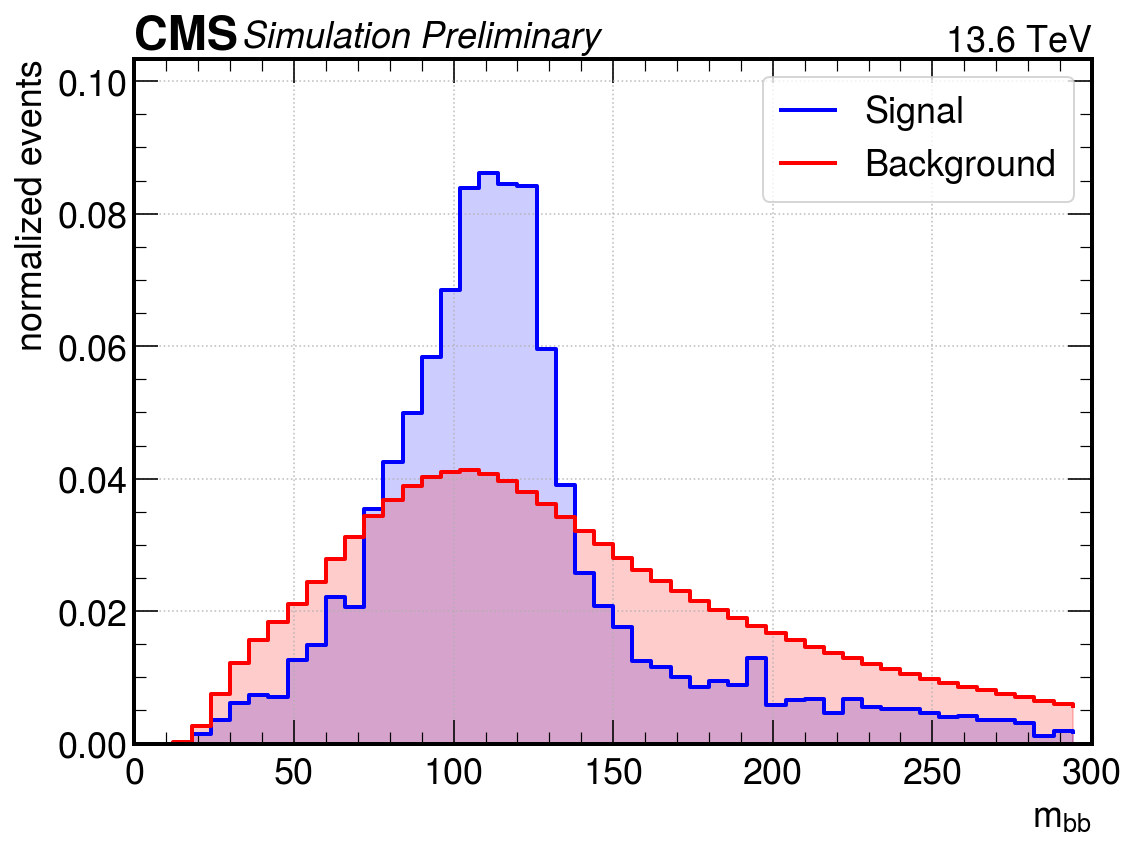

/afs/cern.ch/user/a/anunezde/bamboodev/hh/utils/plotter.py:124: RuntimeWarning: divide by zero encountered in log
  lr_vals = np.log(ratio_vals) if take_log else ratio_vals


Error saving figure: 'NoneType' object has no attribute 'write'


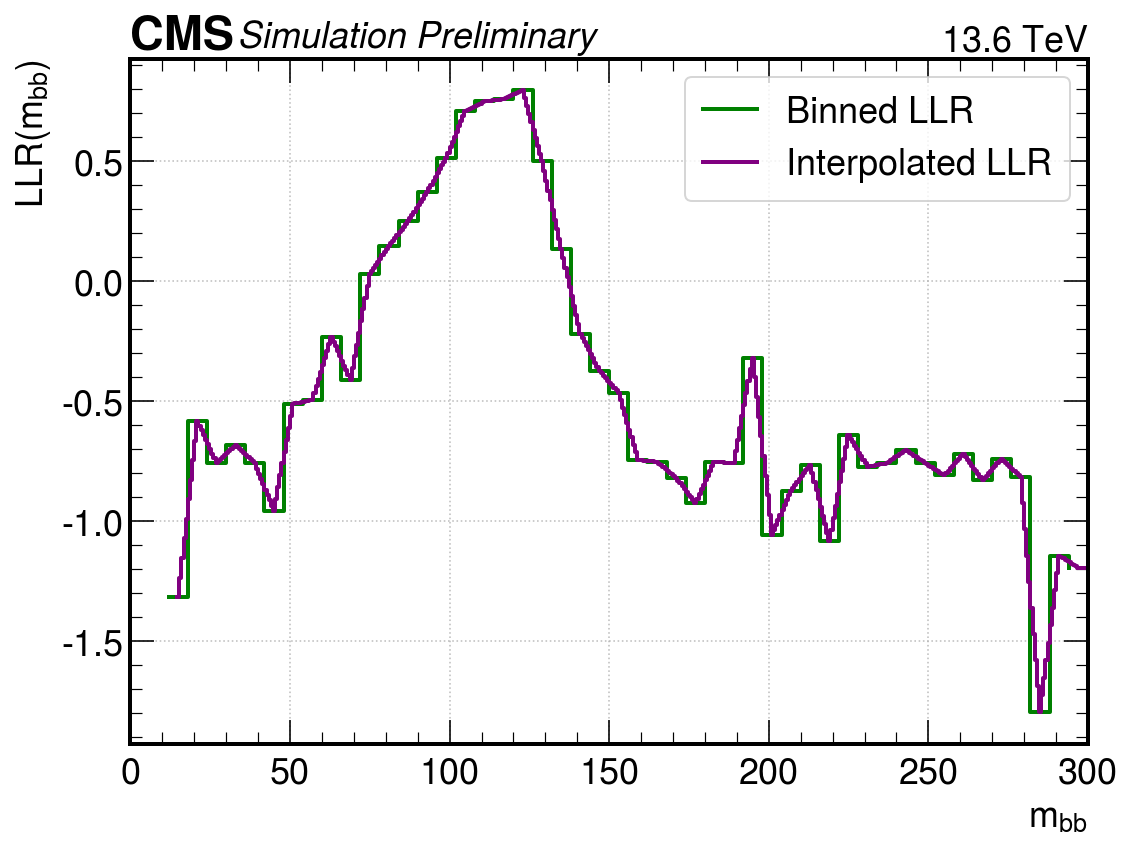

In [9]:
config = AnalysisConfig('bamboo_hh/config/disc_study_new.yml')
plotter = Plotter(config, wd)
plotter.sig_bkg(refs1D[7])
mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/llr_functions.json')
plotter.lr_mapping(refs1D[7], mapping_path)

Figure saved to SL_4j_resolved___bjet_bijet_dR_vs_bjets_mbb___signal.pdf


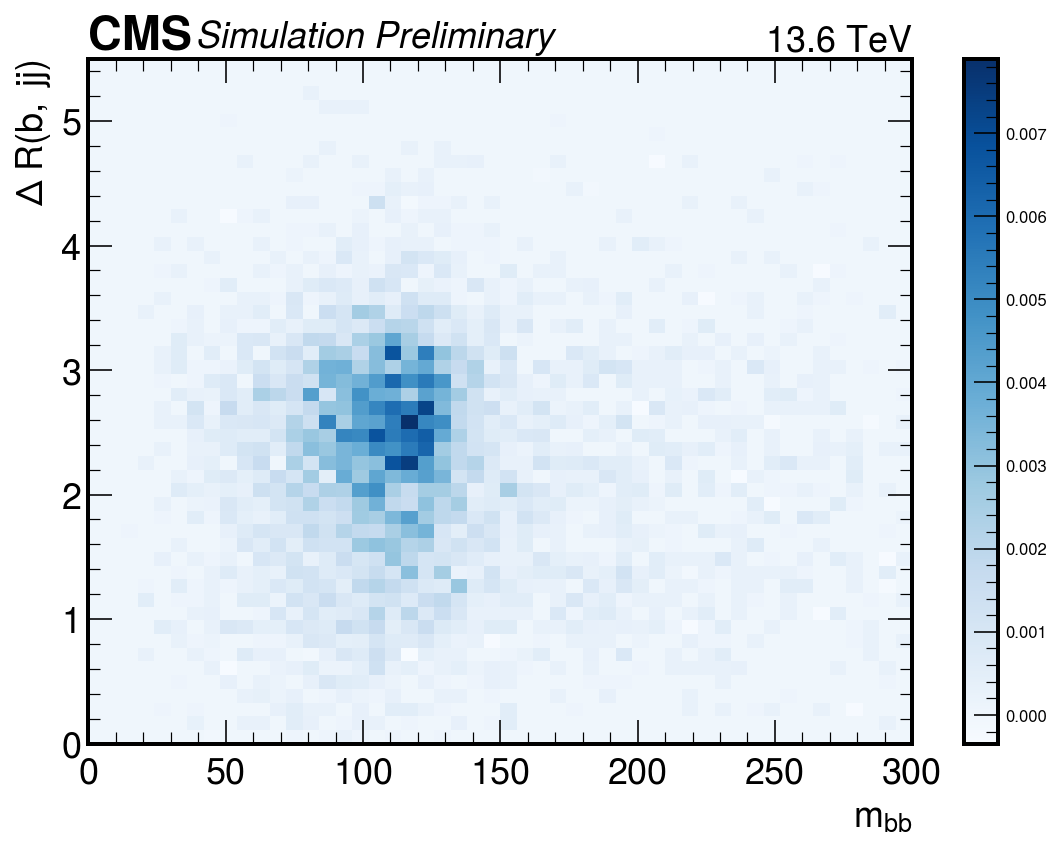

Figure saved to SL_4j_resolved___bjet_bijet_dR_vs_bjets_mbb___signal___bkg.pdf


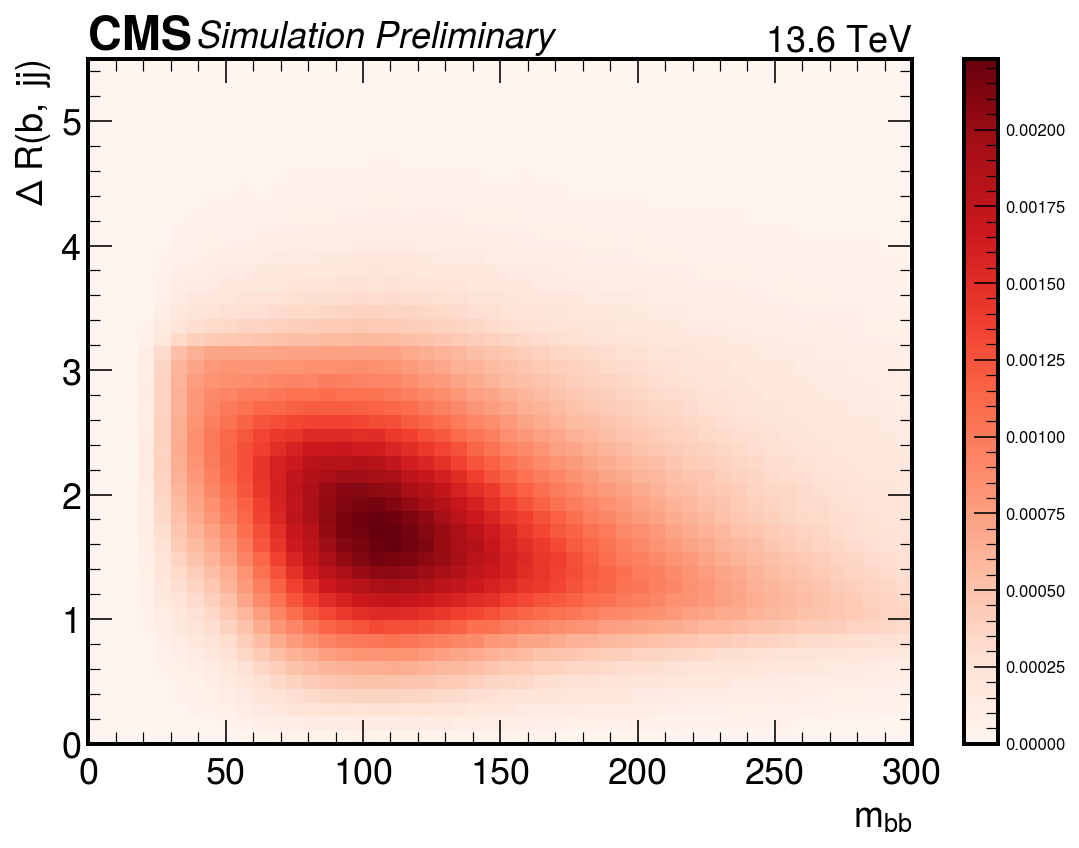

/afs/cern.ch/user/a/anunezde/bamboodev/hh/utils/plotter.py:149: RuntimeWarning: divide by zero encountered in log
  values = np.log(ratio_vals) if take_log else ratio_vals
/afs/cern.ch/user/a/anunezde/bamboodev/hh/utils/plotter.py:149: RuntimeWarning: invalid value encountered in log
  values = np.log(ratio_vals) if take_log else ratio_vals


Figure saved to lr_function_2d.pdf


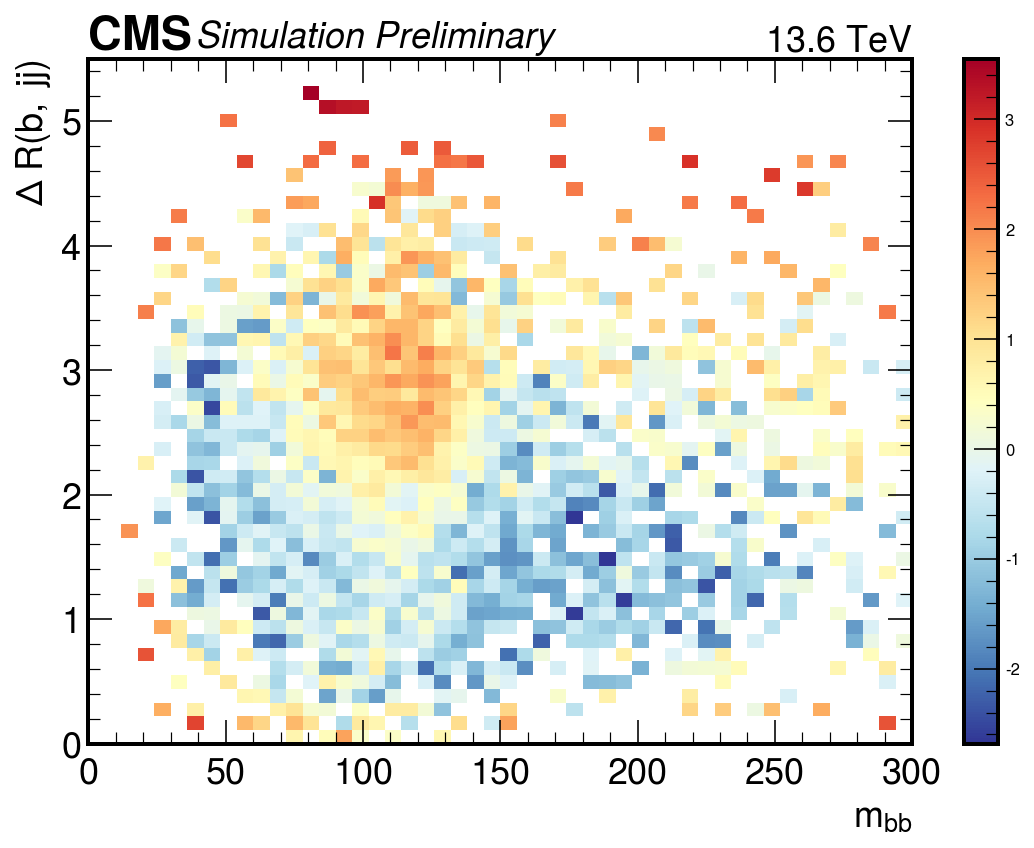

In [10]:
ref = refs2D[28]
plotter.sig_bkg_2d(ref)
plotter.lr_mapping_2d(ref)

## LLR_crtd_odd

In [ ]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd')
wd = WorkDirectory(workdir)
refs = wd.get_refs(selections=['SL_4j_resolved'])

In [12]:
llrs_list = [f'{var_name}_llr' for var_name in curated_list]
refs_llrs_from_1D = list(filter(lambda ref: ref.observable_base in llrs_list, refs))
for i, ref in enumerate(refs_llrs_from_1D):
    print(i+1, ref.name)

1 SL_4j_resolved___all_sT_llr
2 SL_4j_resolved___bb_lnu_dPhi_llr
3 SL_4j_resolved___bb_lnu_dR_llr
4 SL_4j_resolved___bjet_bijet_dR_llr
5 SL_4j_resolved___bjets_dEta_llr
6 SL_4j_resolved___bjets_dPhi_llr
7 SL_4j_resolved___bjets_dR_llr
8 SL_4j_resolved___bjets_mbb_llr
9 SL_4j_resolved___bjets_pt_bb_llr
10 SL_4j_resolved___blnu_mT_llr
11 SL_4j_resolved___blnu_pt_llr
12 SL_4j_resolved___jj_lnu_dPhi_llr
13 SL_4j_resolved___met_pt_llr
14 SL_4j_resolved___trijet_bijet_dEta_llr


Figure saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bb_lnu_dR_llr.pdf


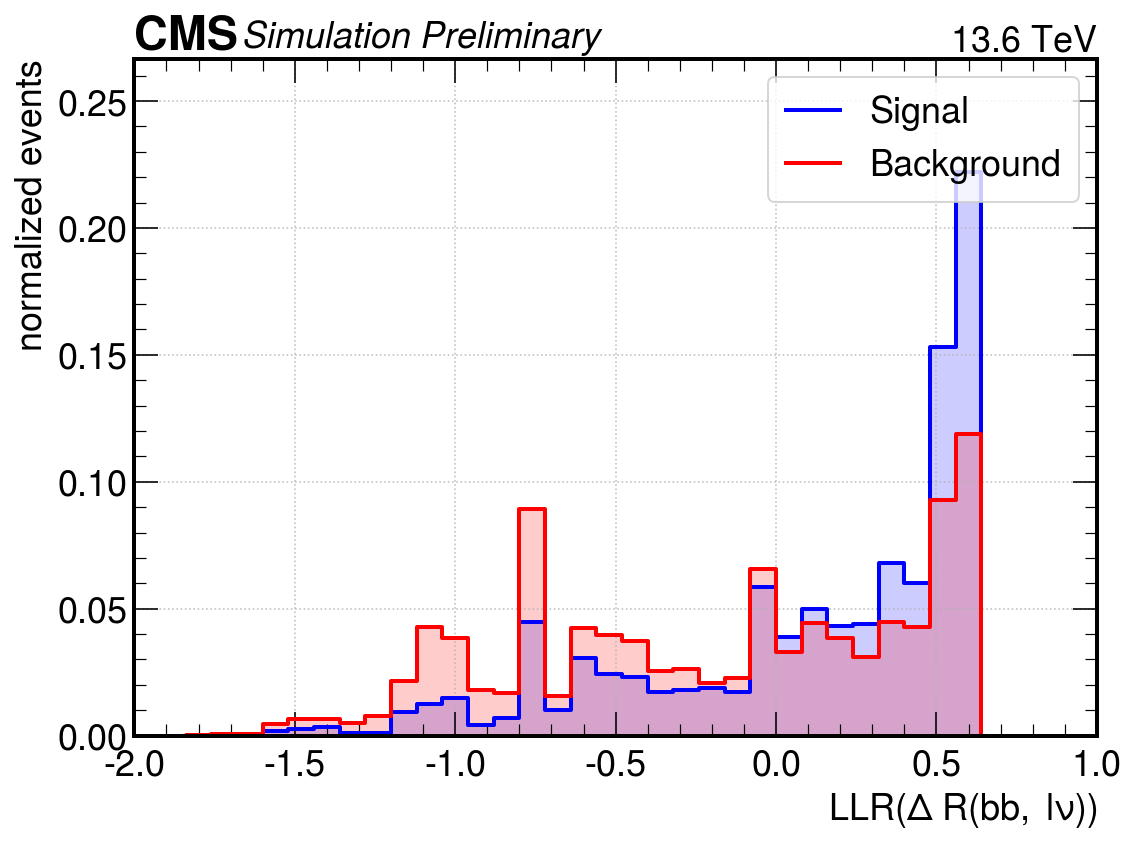

Figure saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bjet_bijet_dR_vs_bjets_mbb_llr.pdf


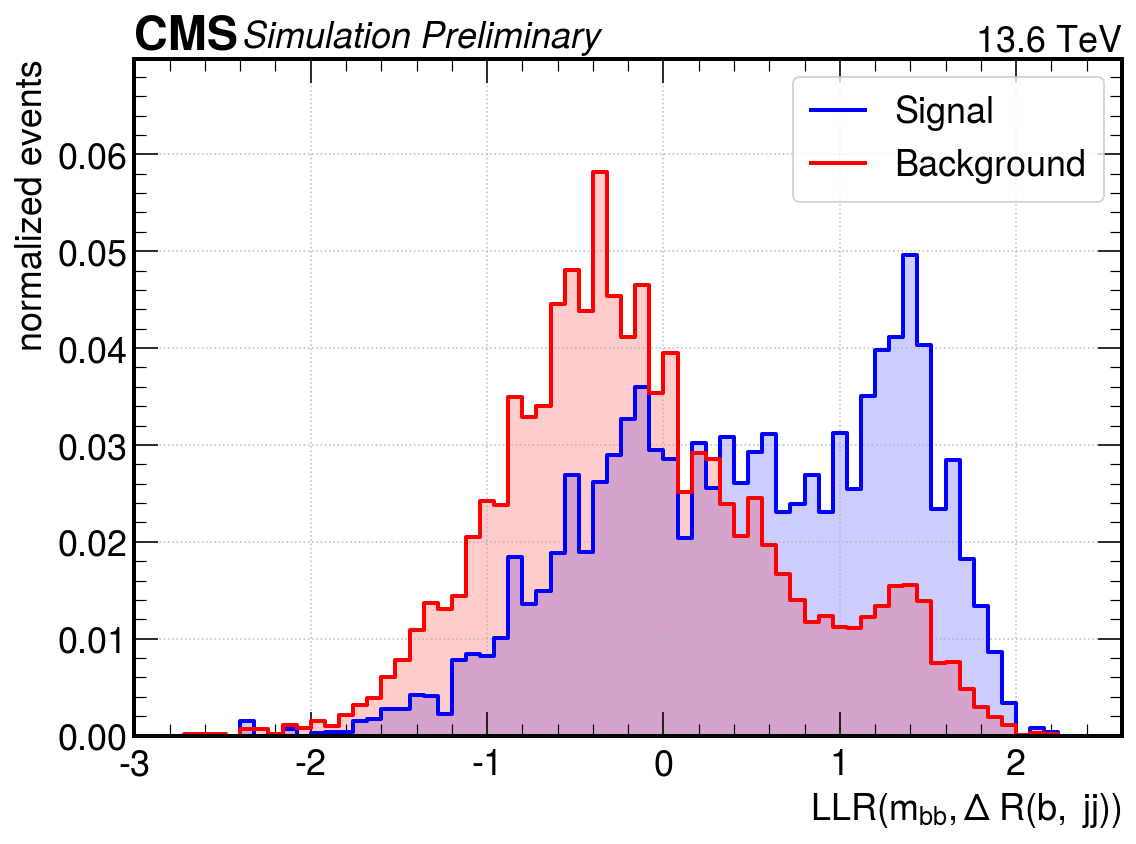

In [13]:
plotter = Plotter(config, wd)
this_biv_llr = Reference('SL_4j_resolved___bjet_bijet_dR_vs_bjets_mbb_llr')
plotter.plot_llr_from_1D(refs_llrs_from_1D[2], -2, 1)
plotter.plot_llr_from_2D(this_biv_llr, -3, 2.6)